In [1]:
import pandas as pd
import numpy as np
import numpy.random as rand
import scipy.stats
import matplotlib as mpl
import matplotlib.pyplot as plt

/sw/pkgs/arc/python3.9-anaconda/2021.11/lib/python3.9/site-packages/scipy/__init__.py:146: UserWarning: A NumPy version >=1.16.5 and <1.23.0 is required for this version of SciPy (detected version 1.26.4
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"


In [ ]:
# In terminal
cd /scratch/humgen551w26_class_root/humgen551w26_class/shared_data/group4/

# Download fastq files from SRA
fasterq-dump SRR21012525 -O /scratch/humgen551w26_class_root/humgen551w26_class/shared_data/group4/
fasterq-dump SRR21012526 -O /scratch/humgen551w26_class_root/humgen551w26_class/shared_data/group4/
fasterq-dump SRR21012529 -O /scratch/humgen551w26_class_root/humgen551w26_class/shared_data/group4/
fasterq-dump SRR21012530 -O /scratch/humgen551w26_class_root/humgen551w26_class/shared_data/group4/

fasterq-dump SRR21012527 -O /scratch/humgen551w26_class_root/humgen551w26_class/shared_data/group4/
fasterq-dump SRR21012528 -O /scratch/humgen551w26_class_root/humgen551w26_class/shared_data/group4/
fasterq-dump SRR21012531 -O /scratch/humgen551w26_class_root/humgen551w26_class/shared_data/group4/
fasterq-dump SRR21012532 -O /scratch/humgen551w26_class_root/humgen551w26_class/shared_data/group4/

In [ ]:
# Take a look at one of the files (in terminal)
head SRR21012525.fastq 

#@SRR21012525.1 NB502099:46:H53JCBGX3:1:11101:12040:1052 length=151
#TTCATNTATAGGACAAATACTTTATTTCCANNTNTTTAANAAATATACCATTTTTTTGCTGTGAACTTTCCCAGTAAATTTCTTTTGTACCCATTAGTATTAGAATAATGTTATCTTGTGCGATTGTTAAAACCCTGTTTTATTCCCAGTT
#+SRR21012525.1 NB502099:46:H53JCBGX3:1:11101:12040:1052 length=151
#AAAAA#EEEEEEEEEEEEEEEEEEEEEAAE##E#EEEEE#EEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEAEEEAEEEAEEE/EEE/<EEEEEEEAEEEEAEEEEE/E/EEEEEE<EEEEEEEEE/<EEEEEEAEAE<EEEA6EAAEEEA
#@SRR21012525.2 NB502099:46:H53JCBGX3:1:11101:7214:1053 length=151
#GCTATNATGTGTCTTTAAGAGTTTGCCTCANNTNTCACAGGTTCATCATCTTGTATGAACTTCTTTAGTAATATTTGTGTGTAATACTCAGAGATTTTTTTTTTTTTTGGTTTTTGTTTTCATAGATTAGAAATGTGTTTACAATCTCCGT
#+SRR21012525.2 NB502099:46:H53JCBGX3:1:11101:7214:1053 length=151
#AAAAA#EEEEEEEEEEEEEEEEEEEEEEEE##E#EEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEAEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEAEEEEE//AEE/E/EEE</E/A/EEE//EAE//A/EEE//A<//<<</<
#@SRR21012525.3 NB502099:46:H53JCBGX3:1:11101:11809:1056 length=150
#GAGCANAGACCTGCTGTTCATCTTGACTGCTAAATACAATGCCTGTATCTTGGAGTATAAGCAGAGTGGCGAAAGCATTGACATCATTACAAGAGCCCATGGCAATGTCCAGGACCGCATTGGTCGCCCCTCGGAGACTGGCATCATTGG

In [ ]:
# Estimate gene abundance for each sample using kallisto (in terminal)
module load Bioinformatics
module load kallisto/0.46.0

# Generate index of mouse transcriptome from Gencode
wget -c https://ftp.ebi.ac.uk/pub/databases/gencode/Gencode_mouse/release_M35/gencode.vM35.transcripts.fa.gz
gunzip gencode.vM35.transcripts.fa.gz
kallisto index -i gencode_vM35.index gencode.vM35.transcripts.fa

# Generate gene counts for each sample 
    # --single = single-end reads
    # -l = average fragment length (usually around 200-300bp)
    # -s = standard deviation of fragment length (usually around 20-30)
kallisto quant --plaintext --single -l 200 -s 20 -i /scratch/humgen551w26_class_root/humgen551w26_class/shared_data/group4/gencode_vM35.index -o Acute_1_SRR21012525 SRR21012525.fastq
kallisto quant --plaintext --single -l 200 -s 20 -i /scratch/humgen551w26_class_root/humgen551w26_class/shared_data/group4/gencode_vM35.index -o Acute_2_SRR21012526 SRR21012526.fastq
kallisto quant --plaintext --single -l 200 -s 20 -i /scratch/humgen551w26_class_root/humgen551w26_class/shared_data/group4/gencode_vM35.index -o Acute_3_SRR21012529 SRR21012529.fastq
kallisto quant --plaintext --single -l 200 -s 20 -i /scratch/humgen551w26_class_root/humgen551w26_class/shared_data/group4/gencode_vM35.index -o Acute_4_SRR21012530 SRR21012530.fastq

kallisto quant --plaintext --single -l 200 -s 20 -i /scratch/humgen551w26_class_root/humgen551w26_class/shared_data/group4/gencode_vM35.index -o Chronic_1_SRR21012527 SRR21012527.fastq
kallisto quant --plaintext --single -l 200 -s 20 -i /scratch/humgen551w26_class_root/humgen551w26_class/shared_data/group4/gencode_vM35.index -o Chronic_2_SRR21012528 SRR21012528.fastq
kallisto quant --plaintext --single -l 200 -s 20 -i /scratch/humgen551w26_class_root/humgen551w26_class/shared_data/group4/gencode_vM35.index -o Chronic_3_SRR21012531 SRR21012531.fastq
kallisto quant --plaintext --single -l 200 -s 20 -i /scratch/humgen551w26_class_root/humgen551w26_class/shared_data/group4/gencode_vM35.index -o Chronic_4_SRR21012532 SRR21012532.fastq


# The resulting output will include TPM estimates for each transcript target.

In [5]:
# Read in the kallisto data

Acute_1 = pd.read_csv('/scratch/humgen551w26_class_root/humgen551w26_class/shared_data/group4/Acute/Acute_1_SRR21012525/abundance.tsv', sep="\t")
Acute_2 = pd.read_csv('/scratch/humgen551w26_class_root/humgen551w26_class/shared_data/group4/Acute/Acute_2_SRR21012526/abundance.tsv', sep="\t")
Acute_3 = pd.read_csv('/scratch/humgen551w26_class_root/humgen551w26_class/shared_data/group4/Acute/Acute_3_SRR21012529/abundance.tsv', sep="\t")
Acute_4 = pd.read_csv('/scratch/humgen551w26_class_root/humgen551w26_class/shared_data/group4/Acute/Acute_4_SRR21012530/abundance.tsv', sep="\t")

Chronic_1 = pd.read_csv('/scratch/humgen551w26_class_root/humgen551w26_class/shared_data/group4/Chronic/Chronic_1_SRR21012527/abundance.tsv', sep="\t")
Chronic_2 = pd.read_csv('/scratch/humgen551w26_class_root/humgen551w26_class/shared_data/group4/Chronic/Chronic_2_SRR21012528/abundance.tsv', sep="\t")
Chronic_3 = pd.read_csv('/scratch/humgen551w26_class_root/humgen551w26_class/shared_data/group4/Chronic/Chronic_3_SRR21012531/abundance.tsv', sep="\t")
Chronic_4 = pd.read_csv('/scratch/humgen551w26_class_root/humgen551w26_class/shared_data/group4/Chronic/Chronic_4_SRR21012532/abundance.tsv', sep="\t")


# Split up the target_id column since theres a ton of columns combined into one (separated by |)
Acute_1[['transcript_id', 'gene_id', 'idk', 'idk2', 'transcript_name', 'gene_name', 'transcript_length', 'type', 'extra']] = Acute_1['target_id'].str.split('|', expand=True)
Acute_2[['transcript_id', 'gene_id', 'idk', 'idk2', 'transcript_name', 'gene_name', 'transcript_length', 'type', 'extra']] = Acute_2['target_id'].str.split('|', expand=True)
Acute_3[['transcript_id', 'gene_id', 'idk', 'idk2', 'transcript_name', 'gene_name', 'transcript_length', 'type', 'extra']] = Acute_3['target_id'].str.split('|', expand=True)
Acute_4[['transcript_id', 'gene_id', 'idk', 'idk2', 'transcript_name', 'gene_name', 'transcript_length', 'type', 'extra']] = Acute_4['target_id'].str.split('|', expand=True)

Chronic_1[['transcript_id', 'gene_id', 'idk', 'idk2', 'transcript_name', 'gene_name', 'transcript_length', 'type', 'extra']] = Chronic_1['target_id'].str.split('|', expand=True)
Chronic_2[['transcript_id', 'gene_id', 'idk', 'idk2', 'transcript_name', 'gene_name', 'transcript_length', 'type', 'extra']] = Chronic_2['target_id'].str.split('|', expand=True)
Chronic_3[['transcript_id', 'gene_id', 'idk', 'idk2', 'transcript_name', 'gene_name', 'transcript_length', 'type', 'extra']] = Chronic_3['target_id'].str.split('|', expand=True)
Chronic_4[['transcript_id', 'gene_id', 'idk', 'idk2', 'transcript_name', 'gene_name', 'transcript_length', 'type', 'extra']] = Chronic_4['target_id'].str.split('|', expand=True)


In [3]:
Acute_1

,target_id,length,eff_length,est_counts,tpm,transcript_id,gene_id,idk,idk2,transcript_name,gene_name,transcript_length,type,extra
0,ENSMUST00000193812.2|ENSMUSG00000102693.2|OTTM...,1070,871.00000,0.0,0.000,ENSMUST00000193812.2,ENSMUSG00000102693.2,OTTMUSG00000049935.1,OTTMUST00000127109.1,4933401J01Rik-201,4933401J01Rik,1070,TEC,
1,ENSMUST00000082908.3|ENSMUSG00000064842.3|-|-|...,110,4.62459,0.0,0.000,ENSMUST00000082908.3,ENSMUSG00000064842.3,-,-,Gm26206-201,Gm26206,110,snRNA,
2,ENSMUST00000162897.2|ENSMUSG00000051951.6|OTTM...,4153,3954.00000,0.0,0.000,ENSMUST00000162897.2,ENSMUSG00000051951.6,OTTMUSG00000026353.2,OTTMUST00000086625.1,Xkr4-203,Xkr4,4153,protein_coding_CDS_not_defined,
3,ENSMUST00000159265.2|ENSMUSG00000051951.6|OTTM...,2989,2790.00000,0.0,0.000,ENSMUST00000159265.2,ENSMUSG00000051951.6,OTTMUSG00000026353.2,OTTMUST00000086624.1,Xkr4-202,Xkr4,2989,protein_coding_CDS_not_defined,
4,ENSMUST00000070533.5|ENSMUSG00000051951.6|OTTM...,3634,3435.00000,0.0,0.000,ENSMUST00000070533.5,ENSMUSG00000051951.6,OTTMUSG00000026353.2,OTTMUST00000065166.1,Xkr4-201,Xkr4,3634,protein_coding,
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
149133,ENSMUST00000082419.1|ENSMUSG00000064368.1|-|-|...,519,320.00000,675.0,483.823,ENSMUST00000082419.1,ENSMUSG00000064368.1,-,-,mt-Nd6-201,mt-Nd6,519,protein_coding,
149134,ENSMUST00000082420.1|ENSMUSG00000064369.1|-|-|...,69,3.46281,0.0,0.000,ENSMUST00000082420.1,ENSMUSG00000064369.1,-,-,mt-Te-201,mt-Te,69,Mt_tRNA,
149135,ENSMUST00000082421.1|ENSMUSG00000064370.1|-|-|...,1144,945.00000,8983.0,2180.330,ENSMUST00000082421.1,ENSMUSG00000064370.1,-,-,mt-Cytb-201,mt-Cytb,1144,protein_coding,
149136,ENSMUST00000082422.1|ENSMUSG00000064371.1|-|-|...,67,3.42238,0.0,0.000,ENSMUST00000082422.1,ENSMUSG00000064371.1,-,-,mt-Tt-201,mt-Tt,67,Mt_tRNA,


In [6]:
# Change count and tpm column names to be unique
Acute_1 = Acute_1.rename(columns={'est_counts': 'Acute_1_counts'})
Acute_2 = Acute_2.rename(columns={'est_counts': 'Acute_2_counts'})
Acute_3 = Acute_3.rename(columns={'est_counts': 'Acute_3_counts'})
Acute_4 = Acute_4.rename(columns={'est_counts': 'Acute_4_counts'})

Chronic_1 = Chronic_1.rename(columns={'est_counts': 'Chronic_1_counts'})
Chronic_2 = Chronic_2.rename(columns={'est_counts': 'Chronic_2_counts'})
Chronic_3 = Chronic_3.rename(columns={'est_counts': 'Chronic_3_counts'})
Chronic_4 = Chronic_4.rename(columns={'est_counts': 'Chronic_4_counts'})

Acute_1 = Acute_1.rename(columns={'tpm': 'Acute_1_tpm'})
Acute_2 = Acute_2.rename(columns={'tpm': 'Acute_2_tpm'})
Acute_3 = Acute_3.rename(columns={'tpm': 'Acute_3_tpm'})
Acute_4 = Acute_4.rename(columns={'tpm': 'Acute_4_tpm'})

Chronic_1 = Chronic_1.rename(columns={'tpm': 'Chronic_1_tpm'})
Chronic_2 = Chronic_2.rename(columns={'tpm': 'Chronic_2_tpm'})
Chronic_3 = Chronic_3.rename(columns={'tpm': 'Chronic_3_tpm'})
Chronic_4 = Chronic_4.rename(columns={'tpm': 'Chronic_4_tpm'})



# Select just gene name, counts, and tpm columns
Acute_1 = Acute_1.iloc[:, [4, 10]]   
Acute_2 = Acute_2.iloc[:, [4, 10]]   
Acute_3 = Acute_3.iloc[:, [4, 10]]   
Acute_4 = Acute_4.iloc[:, [4, 10]]   

Chronic_1 = Chronic_1.iloc[:, [4, 10]]   
Chronic_2 = Chronic_2.iloc[:, [4, 10]]   
Chronic_3 = Chronic_3.iloc[:, [4, 10]]   
Chronic_4 = Chronic_4.iloc[:, [4, 10]]  



# Set index as gene_name
Acute_1 = Acute_1.set_index('gene_name')
Acute_2 = Acute_2.set_index('gene_name')
Acute_3 = Acute_3.set_index('gene_name')
Acute_4 = Acute_4.set_index('gene_name')

Chronic_1 = Chronic_1.set_index('gene_name')
Chronic_2 = Chronic_2.set_index('gene_name')
Chronic_3 = Chronic_3.set_index('gene_name')
Chronic_4 = Chronic_4.set_index('gene_name')

In [7]:
Acute_1

,Acute_1_tpm
gene_name,
4933401J01Rik,0.000
Gm26206,0.000
Xkr4,0.000
Xkr4,0.000
Xkr4,0.000
...,...
mt-Nd6,483.823
mt-Te,0.000
mt-Cytb,2180.330


In [9]:
# Merge all samples into one dataframe

merged_data = pd.concat([Acute_1, Acute_2, Acute_3, Acute_4, Chronic_1, Chronic_2, Chronic_3, Chronic_4], axis = 1)  # axis=1 means to combine columns
merged_data

,Acute_1_tpm,Acute_2_tpm,Acute_3_tpm,Acute_4_tpm,Chronic_1_tpm,Chronic_2_tpm,Chronic_3_tpm,Chronic_4_tpm
gene_name,,,,,,,,
4933401J01Rik,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000
Gm26206,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000
Xkr4,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000
Xkr4,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000
Xkr4,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000
...,...,...,...,...,...,...,...,...
mt-Nd6,483.823,470.655,425.228,490.328,298.389,230.916,248.802,291.717
mt-Te,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000
mt-Cytb,2180.330,1994.490,2147.960,1938.160,1917.510,1934.060,1971.460,1806.280


In [11]:
# Log2 transform the tpm data
merged_data_log = np.log2(merged_data + 1)
merged_data_log

,Acute_1_tpm,Acute_2_tpm,Acute_3_tpm,Acute_4_tpm,Chronic_1_tpm,Chronic_2_tpm,Chronic_3_tpm,Chronic_4_tpm
gene_name,,,,,,,,
4933401J01Rik,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
Gm26206,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
Xkr4,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
Xkr4,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
Xkr4,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
...,...,...,...,...,...,...,...,...
mt-Nd6,8.921314,8.881588,8.735482,8.940543,8.225877,7.857459,7.964641,8.193363
mt-Te,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
mt-Cytb,11.090992,10.962527,11.069423,10.921216,10.905771,10.918163,10.945780,10.819604


In [20]:
# Look at an example "Exhaustion" gene (should be higher in Chronic samples)
merged_data_log_gene = merged_data_log.loc['Pdcd1']
merged_data_log_gene

Acute_1_tpm      4.561894
Acute_2_tpm      4.467899
Acute_3_tpm      4.270110
Acute_4_tpm      4.523480
Chronic_1_tpm    7.647322
Chronic_2_tpm    7.718266
Chronic_3_tpm    7.770162
Chronic_4_tpm    7.624810
Name: Pdcd1, dtype: float64

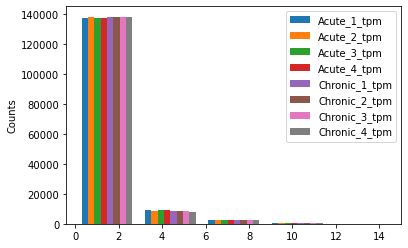

In [18]:
# Make a histogram of the log2(tpm) counts for each sample
_ = plt.hist(merged_data_log, bins=5, label=merged_data_log.columns)
_ = plt.ylabel('Counts')
_ = plt.legend()

In [27]:
# PCA PLOT
# Input is log2-transformed data with samples in rows

# First, transpose columns into rows
merged_data_transposed = merged_data_log.T
merged_data_transposed

gene_name,4933401J01Rik,Gm26206,Xkr4,Xkr4,Xkr4,Gm18956,Gm37180,Gm37363,Gm37686,Gm1992,...,mt-Nd4,mt-Th,mt-Ts2,mt-Tl2,mt-Nd5,mt-Nd6,mt-Te,mt-Cytb,mt-Tt,mt-Tp
Acute_1_tpm,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,9.360186,0.0,0.0,0.0,8.877505,8.921314,0.0,11.090992,0.0,0.0
Acute_2_tpm,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,9.196477,0.0,0.0,0.0,8.734821,8.881588,0.0,10.962527,0.0,0.0
Acute_3_tpm,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,9.360566,0.0,0.0,0.0,8.861155,8.735482,0.0,11.069423,0.0,0.0
Acute_4_tpm,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,9.192616,0.0,0.0,0.0,8.745910,8.940543,0.0,10.921216,0.0,0.0
Chronic_1_tpm,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,8.654869,0.0,0.0,0.0,8.176432,8.225877,0.0,10.905771,0.0,0.0
Chronic_2_tpm,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,8.528872,0.0,0.0,0.0,8.180456,7.857459,0.0,10.918163,0.0,0.0
Chronic_3_tpm,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,8.473961,0.0,0.0,0.0,8.159331,7.964641,0.0,10.945780,0.0,0.0
Chronic_4_tpm,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,8.343226,0.0,0.0,0.0,8.135124,8.193363,0.0,10.819604,0.0,0.0


In [28]:
# Next, scale data

from sklearn.preprocessing import StandardScaler
scaled_data = StandardScaler().fit_transform(merged_data_transposed)
scaled_data

array([[ 0.        ,  0.        ,  0.        , ...,  1.65031285,
         0.        ,  0.        ],
       [ 0.        ,  0.        ,  0.        , ...,  0.10063888,
         0.        ,  0.        ],
       [ 0.        ,  0.        ,  0.        , ...,  1.39012088,
         0.        ,  0.        ],
       ...,
       [ 0.        ,  0.        ,  0.        , ..., -0.43453334,
         0.        ,  0.        ],
       [ 0.        ,  0.        ,  0.        , ..., -0.10138034,
         0.        ,  0.        ],
       [ 0.        ,  0.        ,  0.        , ..., -1.62344222,
         0.        ,  0.        ]])

In [31]:
# Finally, run PCA

from sklearn.decomposition import PCA

pca = PCA(n_components=2)
pca_results = pca.fit_transform(scaled_data)

# Make dataframe with PCA values for plotting
pca_df = pd.DataFrame(data=pca_results, columns=['PC1', 'PC2'])

pca_df


,PC1,PC2
0,148.566304,-173.851627
1,119.291226,-56.408617
2,130.796366,12.676879
3,157.331805,205.975405
4,-139.831132,-4.286625
5,-127.464075,8.223172
6,-140.366529,10.001270
7,-148.323965,-2.329857


No handles with labels found to put in legend.


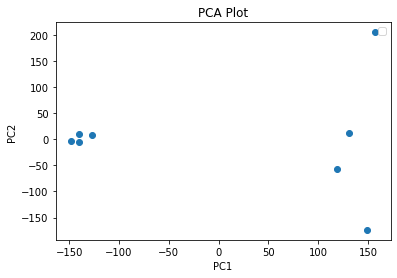

In [35]:
# Generate PCA plot
_ = plt.scatter(pca_df['PC1'], pca_df['PC2'])
_ = plt.xlabel('PC1')
_ = plt.ylabel('PC2')
_ = plt.title('PCA Plot')
_ = plt.legend()

In [ ]:
# Assign each dot to its sample
